dummy-spatialdata is compatible with both spatialdata == 0.5.0 (zarr v2) and 0.7.2 (zarr v3)

Thus please use 
1. conda create --name dummy_sd_env python==3.12 spatialdata==0.7.2
or 
2. conda create --name dummy_sd_env_05 python==3.12 spatialdata==0.5.0 setuptools==75.8.0

In [1]:
from dummy_spatialdata import generate_dataset
from dummy_spatialdata import generate_anndata
import dummy_anndata
import spatialdata_plot as sdp 
import spatialdata as sd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import tempfile as tf
import shutil

/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [2]:
# generate spatialdata
sdata = generate_dataset(
    images = [
        {'type': 'rgb', 'scale_factors': [2,2,2], 'shape': {'x': 64, 'y': 64},
         'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']},
    ],
    labels = [
        {'n': 12, 'scale_factors': [2,2,2],  'shape': {'x': 64, 'y': 64},
         'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']},
    ],
    shapes = [
        {'n': 12, 'type': 'polygon', 'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']},
        {'n': 12, 'type': 'circle', 'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']}
    ],
    points = [
        {'n': 12, 'coordinate_system': ['identity', 'scale', 'mapAxis', 'translation', 'rotation', 'affine', 'sequence']}
    ],
    tables = [
        {'table': generate_anndata(n_obs=12, n_vars=20), 'element': 'shape', 'element_index': 0},
        {'table': generate_anndata(n_obs=12, n_vars=20), 'element': 'shape', 'element_index': 1}
    ],
    coordinate_systems = {
        'identity': {'transformations': ['identity']},
        'scale': {'transformations': ['scale']},
        'mapAxis': {'transformations': ['mapAxis']},
        'translation': {'transformations': ['translation']},
        'rotation': {'transformations': ['rotation']},
        'affine': {'transformations': ['affine']},
        'sequence': {'transformations': ['scale', 'mapAxis', 'translation', 'rotation', 'affine']}
    },
    SEED=13
)
sdata

INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                


/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)
/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)


SpatialData object
├── Images
│     └── 'image_0': DataTree[cyx] (3, 64, 64), (3, 32, 32), (3, 16, 16), (3, 8, 8)
├── Labels
│     └── 'label_0': DataTree[yx] (64, 64), (32, 32), (16, 16), (8, 8)
├── Points
│     └── 'point_0': DataFrame with shape: (<Delayed>, 2) (2D points)
├── Shapes
│     ├── 'shape_0': GeoDataFrame shape: (12, 1) (2D shapes)
│     └── 'shape_1': GeoDataFrame shape: (12, 2) (2D shapes)
└── Tables
      ├── 'table_0': AnnData (12, 20)
      └── 'table_1': AnnData (12, 20)
with coordinate systems:
    ▸ 'affine', with elements:
        image_0 (Images), label_0 (Labels), point_0 (Points), shape_0 (Shapes), shape_1 (Shapes)
    ▸ 'identity', with elements:
        image_0 (Images), label_0 (Labels), point_0 (Points), shape_0 (Shapes), shape_1 (Shapes)
    ▸ 'mapAxis', with elements:
        image_0 (Images), label_0 (Labels), point_0 (Points), shape_0 (Shapes), shape_1 (Shapes)
    ▸ 'rotation', with elements:
        image_0 (Images), label_0 (Labels), point_0 (Point

/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/_core/operations/transform.py:494: UserWarning: The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of the modules of eigenvalues of the affine transformation matrix.
matrix=[[0.3 0.  0. ]
 [0.  1.3 0. ]
 [0.  0.  1. ]]
eigenvalues=[0.3 1.3]
scale_factor=0.8
  new_radii = scale_radii(radii=old_radii, affine=affine, axes=axes)
/Users/amanuky/miniforge3/envs/dummy_sd_env_05/lib/python3.12/site-packages/spatialdata/_core/operations/transform.py:494: UserWarning: The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of the modules of eigenvalues of the affine transformation matrix.
matrix=[[0.5 0.2 0. ]
 [0.1 0.5 0. ]
 [0.  0.  1. ]]
eigenvalues=[0.64142136 0.35857864]
scale_factor=0.5
  new_radii = scale_radii(radii=old_radii, affine=affine, axes=axes)


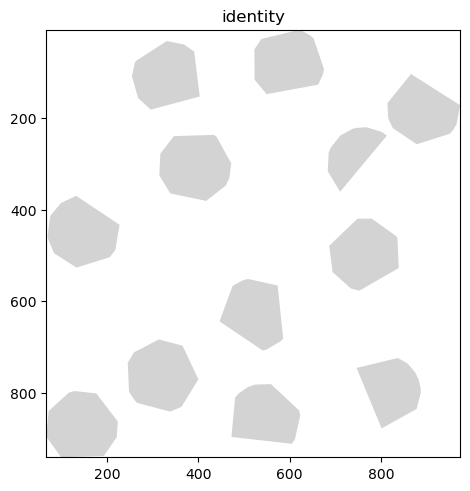

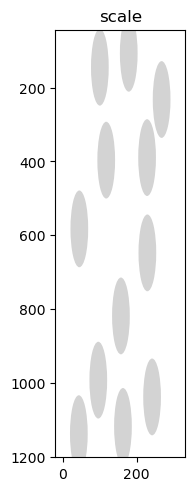

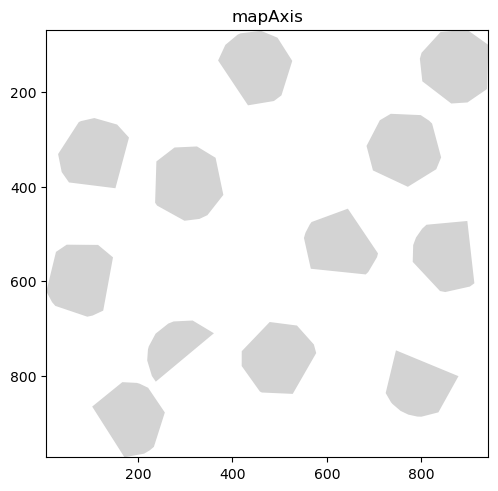

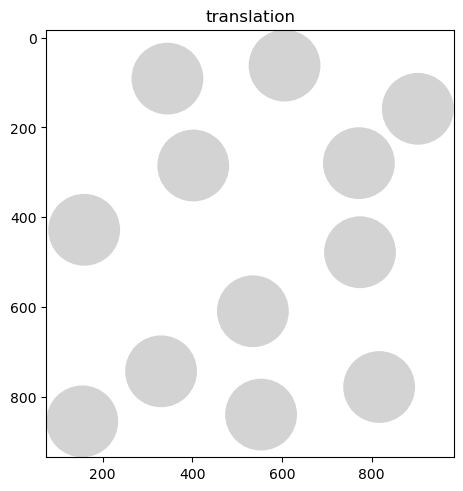

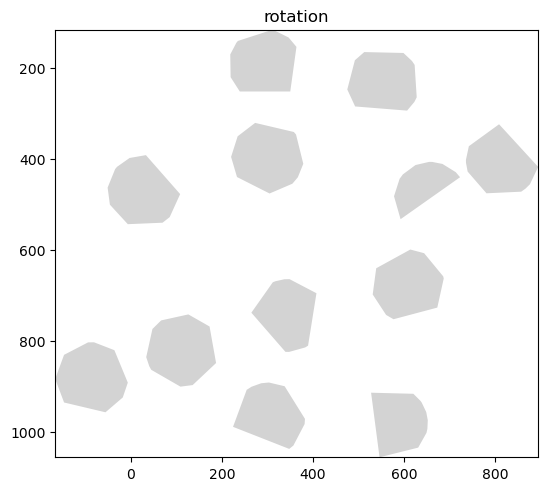

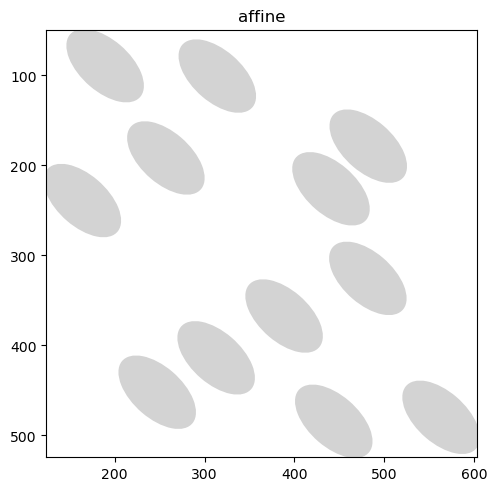

In [4]:
sdata.pl.render_shapes("shape_0", table_name = "table_0").pl.show(coordinate_systems = "identity")
sdata.pl.render_shapes("shape_1", table_name = "table_1").pl.show(coordinate_systems = "scale")
sdata.pl.render_shapes("shape_0", table_name = "table_0").pl.show(coordinate_systems = "mapAxis")
sdata.pl.render_shapes("shape_1", table_name = "table_1").pl.show(coordinate_systems = "translation")
sdata.pl.render_shapes("shape_0", table_name = "table_0").pl.show(coordinate_systems = "rotation")
sdata.pl.render_shapes("shape_1", table_name = "table_1").pl.show(coordinate_systems = "affine")

/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'shape_1', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'shape_2', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'shape_3', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'shape_4', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/amanu

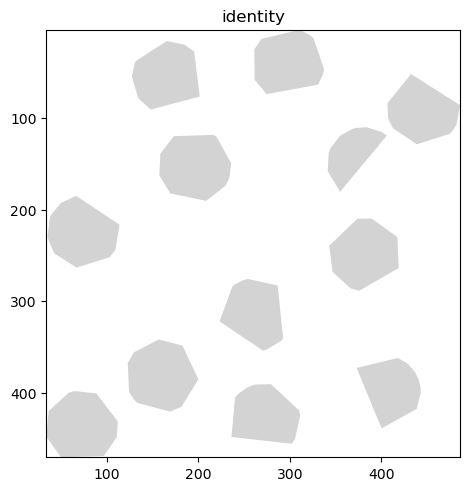

In [13]:
sdata.pl.render_shapes("shape_0", table_name = "table_0").pl.show(coordinate_systems = "identity")
